In [1]:
import numpy as np
import pandas as pd

import statsmodels.api as sm
from scipy.stats import ks_2samp, mannwhitneyu
from sklearn.metrics import average_precision_score

from tqdm.auto import tqdm

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    roc_auc_score, 
    precision_recall_curve,
    classification_report
)
pd.set_option("display.max_rows", None)
from statsmodels.tools.sm_exceptions import PerfectSeparationError

TARGET = "fraud"

%matplotlib inline

In [2]:
df = pd.read_parquet("data")

In [3]:
df["tx_year"] = df["date"].dt.year.astype("int16")

In [4]:
LABEL = "fraud"
MCC_COL = "mcc"          
YEAR_COL = "tx_year"    

def _safe_to_numeric(s):
    return pd.to_numeric(s, errors="coerce")

def ensure_cols(df, cols):
    missing = [c for c in cols if c not in df.columns]
    if missing:
        raise ValueError(f"Missing columns: {missing}")

In [5]:
def build_mcc_stats(df, mcc_col=MCC_COL, label_col=LABEL):
    ensure_cols(df, [mcc_col, label_col])
    g = df.groupby(mcc_col)[label_col].agg(tx_count="count", raw_rate="mean").reset_index()
    g["raw_rate"] = g["raw_rate"].astype(float)
    g["tx_count"] = g["tx_count"].astype(int)
    return g

def add_smoothed_rate(mcc_stats, global_rate, alpha):
    m = mcc_stats.copy()
    m["smoothed_rate"] = (
        (m["raw_rate"] * m["tx_count"] + global_rate * alpha) / (m["tx_count"] + alpha)
    )
    m["alpha"] = alpha
    return m

def compute_smoothed_maps(df, alphas=(100, 500, 1000, 2000), mcc_col=MCC_COL, label_col=LABEL):
    global_rate = float(df[label_col].mean())
    base = build_mcc_stats(df, mcc_col=mcc_col, label_col=label_col)

    out = []
    for a in alphas:
        out.append(add_smoothed_rate(base, global_rate=global_rate, alpha=a))
    mcc_stats_all = pd.concat(out, axis=0, ignore_index=True)
    return global_rate, base, mcc_stats_all

In [6]:
def plot_mcc_volume_longtail(mcc_stats):
    s = mcc_stats.sort_values("tx_count", ascending=False).reset_index(drop=True)
    s["cum_tx"] = s["tx_count"].cumsum()
    s["cum_share"] = s["cum_tx"] / s["tx_count"].sum()

    fig = plt.figure(figsize=(10, 4))
    ax = plt.gca()
    ax.plot(s["cum_share"].values)
    ax.set_title("MCC Long-tail: Cumulative transaction share by MCC rank")
    ax.set_xlabel("MCC rank (sorted by tx_count desc)")
    ax.set_ylabel("Cumulative tx share")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [7]:
def plot_volume_vs_rawrate(mcc_stats, max_points=None):
    s = mcc_stats.copy()

    if max_points is not None and len(s) > max_points:
        s = s.sort_values("tx_count", ascending=False).head(max_points)

    x = s["tx_count"].values
    y = s["raw_rate"].values

    plt.figure(figsize=(8, 5))
    plt.scatter(x, y, s=10, alpha=0.5)
    plt.xscale("log")
    plt.title("Noise proof: tx_count (log) vs raw fraud rate by MCC")
    plt.xlabel("tx_count (log scale)")
    plt.ylabel("raw fraud rate")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [8]:
def plot_alpha_sensitivity(mcc_stats_all, alphas=(100, 500, 1000, 2000)):
    # alpha별 smoothed_rate 요약 통계(분위수) 곡선
    qs = [0.5, 0.75, 0.9, 0.95, 0.99]
    rows = []
    for a in alphas:
        s = mcc_stats_all[mcc_stats_all["alpha"] == a]["smoothed_rate"].values
        for q in qs:
            rows.append((a, q, float(np.quantile(s, q))))
    sens = pd.DataFrame(rows, columns=["alpha", "quantile", "smoothed_rate_q"])

    plt.figure(figsize=(8, 5))
    for q in qs:
        t = sens[sens["quantile"] == q].sort_values("alpha")
        plt.plot(t["alpha"].values, t["smoothed_rate_q"].values, marker="o", label=f"q={q}")
    plt.title("Alpha sensitivity: quantiles of smoothed_rate")
    plt.xlabel("alpha")
    plt.ylabel("smoothed_rate quantile value")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    return sens

In [9]:
def plot_raw_vs_smoothed(mcc_stats_all, alpha=1000, global_rate=None):
    s = mcc_stats_all[mcc_stats_all["alpha"] == alpha].copy()

    x = s["raw_rate"].values
    y = s["smoothed_rate"].values
    size = np.clip(np.log1p(s["tx_count"].values), 1, 10)  # 거래량이 큰 점이 살짝 도드라지게

    plt.figure(figsize=(7, 7))
    plt.scatter(x, y, s=10*size, alpha=0.5)
    plt.plot([0, 1], [0, 1], linestyle="--")  # y=x
    if global_rate is not None:
        plt.axhline(global_rate, linestyle=":", linewidth=1)
    plt.title(f"Raw vs Smoothed (alpha={alpha})")
    plt.xlabel("raw fraud rate")
    plt.ylabel("smoothed fraud risk")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [10]:
def plot_top20_highrisk_mcc(mcc_stats_all, alpha=1000, topn=20):
    s = mcc_stats_all[mcc_stats_all["alpha"] == alpha].copy()
    top = s.sort_values("smoothed_rate", ascending=False).head(topn)

    # barh는 위에서 아래로 읽기 좋게 reverse
    top = top.iloc[::-1]

    plt.figure(figsize=(9, 6))
    plt.barh(top[MCC_COL].astype(str), top["smoothed_rate"].values)
    plt.title(f"Top {topn} high-risk MCC by smoothed_rate (alpha={alpha})")
    plt.xlabel("smoothed_rate")
    plt.tight_layout()
    plt.show()

    return top[[MCC_COL, "tx_count", "raw_rate", "smoothed_rate"]]

In [11]:
def attach_mcc_features(df, mcc_stats_all, alpha=1000, q=0.9, mcc_col=MCC_COL):
    s = mcc_stats_all[mcc_stats_all["alpha"] == alpha].copy()
    thr = float(s["smoothed_rate"].quantile(q))
    s["mcc_is_highrisk"] = (s["smoothed_rate"] >= thr).astype("int8")

    map_sm = s.set_index(mcc_col)["smoothed_rate"].to_dict()
    map_hi = s.set_index(mcc_col)["mcc_is_highrisk"].to_dict()

    out = df.copy()
    out["mcc_smoothed_risk"] = out[mcc_col].map(map_sm).astype(float)
    out["mcc_is_highrisk"] = out[mcc_col].map(map_hi).fillna(0).astype("int8")
    return out, thr, s[[mcc_col, "tx_count", "raw_rate", "smoothed_rate", "mcc_is_highrisk"]]

In [12]:
def top_decile_lift(y_true, score, q=0.90):
    y = pd.Series(y_true).astype(int).reset_index(drop=True)
    s = pd.Series(score).astype(float).reset_index(drop=True)

    base_rate = float(y.mean())
    thr = float(np.quantile(s, q))
    top_mask = s >= thr

    top_n = int(top_mask.sum())
    top_rate = float(y[top_mask].mean()) if top_n > 0 else np.nan
    top_lift = float(top_rate / base_rate) if base_rate > 0 else np.nan

    return dict(base_rate=base_rate, thr=thr, top_n=top_n, top_rate=top_rate, top_lift=top_lift)

In [13]:
def yearwise_topk_overlap(df, alpha=1000, topk=50, year_col=YEAR_COL, mcc_col=MCC_COL, label_col=LABEL):
    ensure_cols(df, [year_col, mcc_col, label_col])

    years = sorted(df[year_col].dropna().unique())
    top_sets = {}

    for y in years:
        sub = df[df[year_col] == y]
        global_rate = float(sub[label_col].mean())
        base = build_mcc_stats(sub, mcc_col=mcc_col, label_col=label_col)
        stats = add_smoothed_rate(base, global_rate=global_rate, alpha=alpha)
        top = stats.sort_values("smoothed_rate", ascending=False).head(topk)[mcc_col].tolist()
        top_sets[y] = set(top)

    # jaccard matrix (year i vs year j)
    mat = np.zeros((len(years), len(years)), dtype=float)
    for i, yi in enumerate(years):
        for j, yj in enumerate(years):
            a = top_sets[yi]; b = top_sets[yj]
            inter = len(a & b)
            union = len(a | b) if len(a | b) > 0 else 1
            mat[i, j] = inter / union

    plt.figure(figsize=(7, 6))
    plt.imshow(mat, aspect="auto")
    plt.colorbar(label="Jaccard overlap")
    plt.xticks(range(len(years)), years, rotation=45)
    plt.yticks(range(len(years)), years)
    plt.title(f"Year-wise Top-{topk} high-risk MCC overlap (alpha={alpha})")
    plt.tight_layout()
    plt.show()

    return years, top_sets, mat

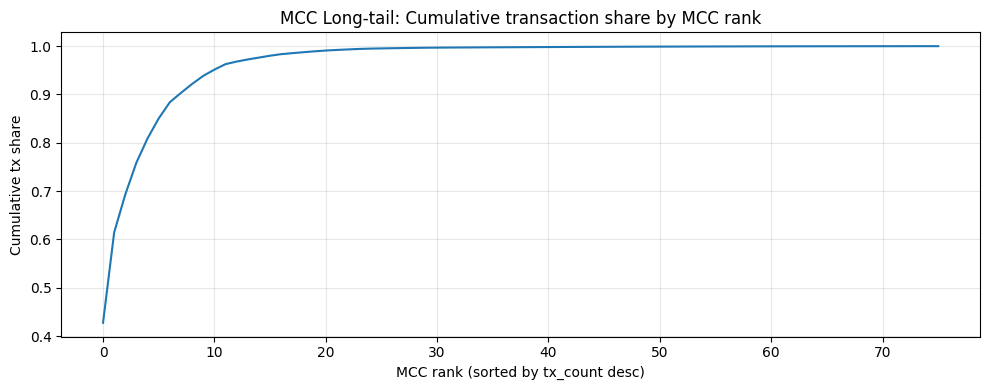

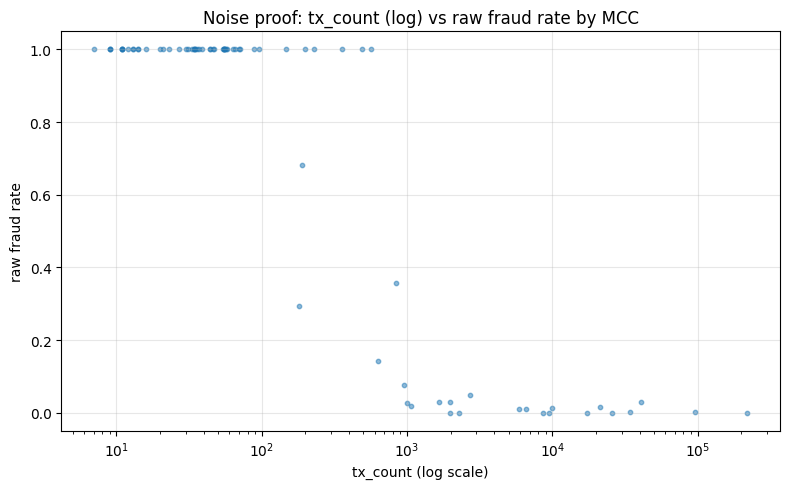

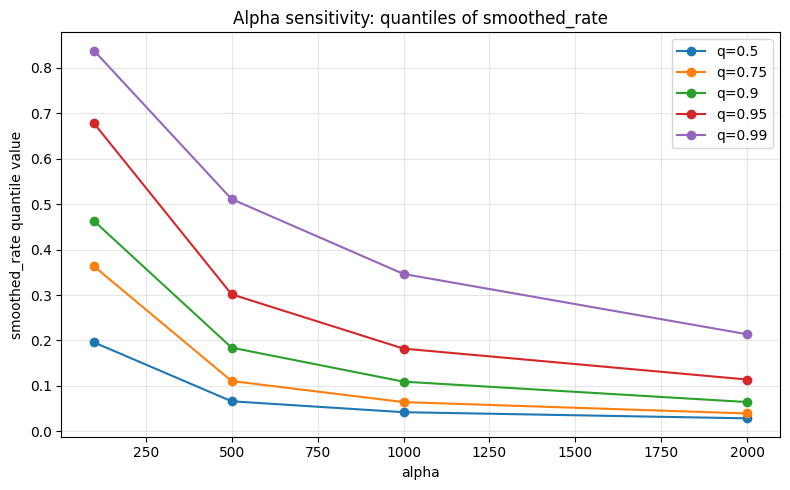

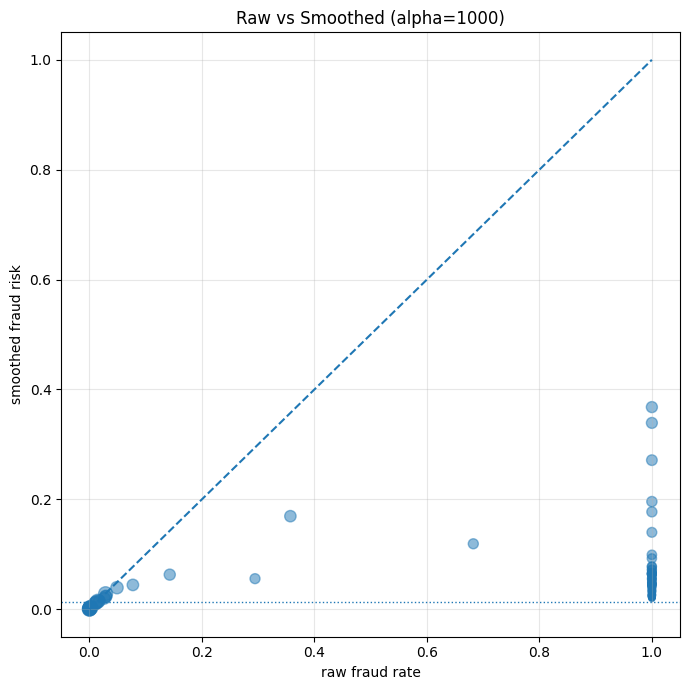

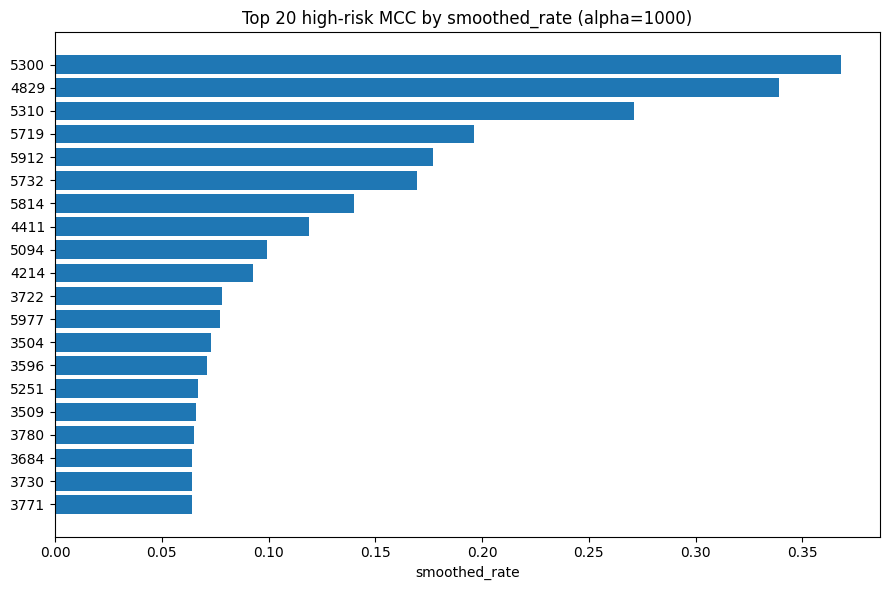

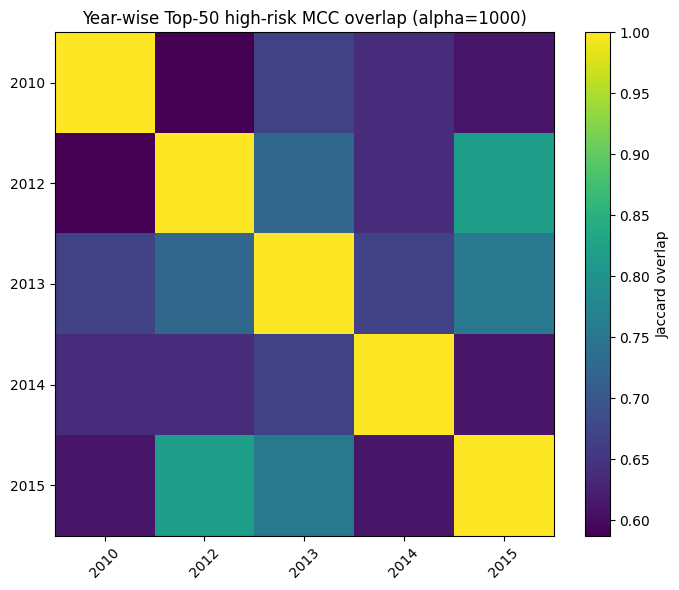

In [14]:
# 0) 준비
ensure_cols(df, [MCC_COL, LABEL, YEAR_COL])

# 1) 전체 데이터 기준 smoothing 준비
alphas = (100, 500, 1000, 2000)
global_rate, mcc_base, mcc_all = compute_smoothed_maps(df, alphas=alphas)

# 2) 시각화 (필수 2장 포함)
plot_mcc_volume_longtail(mcc_base)
plot_volume_vs_rawrate(mcc_base, max_points=3000)       # 시각화용 상위 3000
plot_alpha_sensitivity(mcc_all, alphas=alphas)

plot_raw_vs_smoothed(mcc_all, alpha=1000, global_rate=global_rate)  # 최중요
top20 = plot_top20_highrisk_mcc(mcc_all, alpha=1000, topn=20)

# 3) 피처 부착
df2, thr, mcc_table = attach_mcc_features(df, mcc_all, alpha=1000, q=0.9)

# 4) 연도별 안정성(Top-K overlap)
years, top_sets, jacc = yearwise_topk_overlap(df, alpha=1000, topk=50)

**1. MCC는 극단적 롱테일 구조**

상위 약 5~10개 MCC가 이미 전체 거래의 90% 이상을 차지

이후 MCC들은 거의 수평선에 가까움 (거래량 극소)

-> 극단적 long tail 구조 

=> 소수 MCC가 매우 큰 표본, 다수는 극도로 작은 표본

> MCC raw rate를 그대로 모델에 넣으면 노이즈 피처가 된다.

Smoothing 필수!

**2. Bayesian Smoothing 적용**

> raw_rate=1인 MCC가 다수 존재하지만\
> 그 대부분은 tx_count 매우 작음.

**3. Alpha 민감도 분석**

alpha는 global_rate에 대한 prior strength.

alpha 작음 → raw에 가깝다 → tail 유지

alpha 큼 → 전체가 baseline으로 강하게 수축

alpha=1000:

q0.95 ~0.18

q0.99 ~0.35

→ tail은 남겨두되 폭발적 노이즈는 제거

**4. Raw vs Smoothed 검증**

확인한 것:

raw=1인 저표본 MCC는 baseline 근처로 수축

거래량 충분한 MCC는 raw≈smoothed

전체가 baseline으로 몰리지 않음

결론:

smoothing 정상 작동

**5. Top high-risk MCC 확인**

노이즈 MCC가 상단 독점하지 않음

구조적 위험 업종 분리 가능

**6. 연도별 Top50 overlap**

대부분 0.6~0.85

완전 붕괴 없음

특정 연도에서만 위험 MCC가 싹 바뀌는 현상 없음

즉:

MCC 위험 업종은 상당히 안정적인 구조적 신호

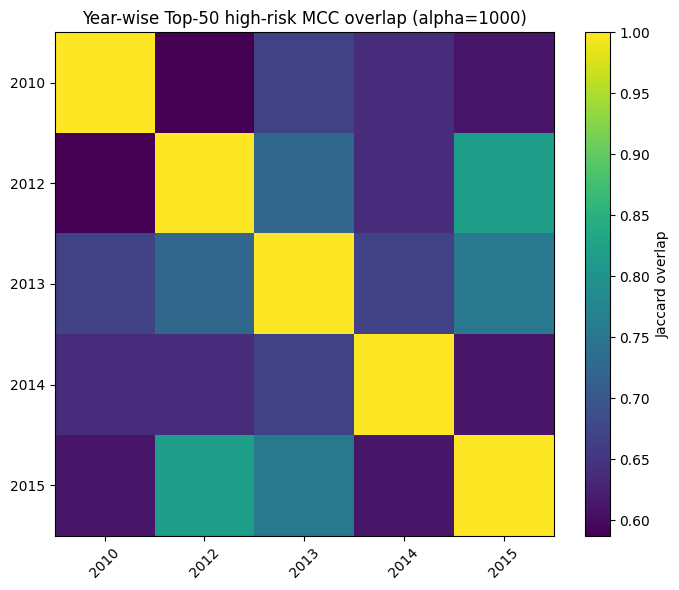

,2010,2012,2013,2014,2015
2010,1.000,0.587,0.667,0.639,0.613
2012,0.587,1.000,0.724,0.639,0.818
2013,0.667,0.724,1.000,0.667,0.754
2014,0.639,0.639,0.667,1.000,0.613
2015,0.613,0.818,0.754,0.613,1.000


In [80]:
years, topk_dict, overlap_matrix = yearwise_topk_overlap(
    df,
    alpha=1000,
    topk=50
)

import pandas as pd

overlap_df = pd.DataFrame(
    overlap_matrix,
    index=years,
    columns=years
)

display(overlap_df.round(3))

- 2012–2015는 꽤 안정적
- 2010은 다른 연도와 유사도가 낮다
- 완전 붕괴(0.2~0.3 수준)가 없다

=> 단기 노이즈 아니라 구조적 신호

---

### 단변량 성능 검증 (MCC 단독 설명력)

ROC AUC / PR AUC

In [15]:
MCC_COL = "mcc"
LABEL = "fraud"
alpha = 1000

# 1. Global fraud rate
global_rate = df[LABEL].mean()

# 2. MCC별 거래수 + raw fraud rate 계산
mcc_stats = (
    df.groupby(MCC_COL)[LABEL]
      .agg(tx_count="count", raw_rate="mean")
      .reset_index()
)

# 3. Bayesian smoothing 적용
mcc_stats["mcc_smoothed_risk"] = (
    (mcc_stats["raw_rate"] * mcc_stats["tx_count"] +
     global_rate * alpha)
    / (mcc_stats["tx_count"] + alpha)
)

# 4. 원본 df에 매핑
df["mcc_smoothed_risk"] = df[MCC_COL].map(
    mcc_stats.set_index(MCC_COL)["mcc_smoothed_risk"]
)

df["mcc_smoothed_risk"] = df["mcc_smoothed_risk"].astype("float32")

print("mcc_smoothed_risk 생성 완료")

mcc_smoothed_risk 생성 완료


In [16]:
df["mcc_smoothed_risk"].describe()

count    515188.000000
mean          0.006173
std           0.021727
min           0.000057
25%           0.000057
50%           0.001019
75%           0.003073
max           0.367913
Name: mcc_smoothed_risk, dtype: float64

In [17]:
y = df["fraud"].values
score = df["mcc_smoothed_risk"].values

print("ROC AUC:", roc_auc_score(y, score))
print("PR AUC :", average_precision_score(y, score))

ROC AUC: 0.9645725073597187
PR AUC : 0.5972046767462866


> 비정상적으로 높은 수치 leakage 발생 때문

-> 아래 과정 통해 확인!

Top-decile Lift

In [18]:
def top_decile_lift(y, score):
    base_rate = y.mean()
    thr = np.quantile(score, 0.9)
    top_mask = score >= thr
    top_rate = y[top_mask].mean()
    return top_rate / base_rate

print("Top-decile lift:", top_decile_lift(y, score))

Top-decile lift: 8.53260146197893


### Logistic OR 분석 (통계적 유의성)

연속형

In [19]:
import statsmodels.api as sm

X = sm.add_constant(df["mcc_smoothed_risk"])
model = sm.Logit(df["fraud"], X).fit()
print(model.summary())

Optimization terminated successfully.
         Current function value: 0.037742
         Iterations 10
                           Logit Regression Results                           
Dep. Variable:                  fraud   No. Observations:               515188
Model:                          Logit   Df Residuals:                   515186
Method:                           MLE   Df Model:                            1
Date:                Mon, 23 Feb 2026   Pseudo R-squ.:                  0.4448
Time:                        06:23:04   Log-Likelihood:                -19444.
converged:                       True   LL-Null:                       -35025.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                -5.5587      0.021   -259.872      0.000      -5.601      -5.517
mcc_smo

이진형

In [20]:
# 상위 10%
q = 0.9

threshold = df["mcc_smoothed_risk"].quantile(q)

df["mcc_is_highrisk"] = (
    df["mcc_smoothed_risk"] >= threshold
).astype("int8")

print("threshold:", threshold)

threshold: 0.023686597123742104


In [21]:
df["mcc_is_highrisk"].value_counts(normalize=True)

mcc_is_highrisk
0    0.899827
1    0.100173
Name: proportion, dtype: float64

In [22]:
X = sm.add_constant(df["mcc_is_highrisk"])
model = sm.Logit(df["fraud"], X).fit()
print(model.summary())

Optimization terminated successfully.
         Current function value: 0.047578
         Iterations 10
                           Logit Regression Results                           
Dep. Variable:                  fraud   No. Observations:               515188
Model:                          Logit   Df Residuals:                   515186
Method:                           MLE   Df Model:                            1
Date:                Mon, 23 Feb 2026   Pseudo R-squ.:                  0.3002
Time:                        06:23:05   Log-Likelihood:                -24512.
converged:                       True   LL-Null:                       -35025.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              -6.1893      0.032   -190.471      0.000      -6.253      -6.126
mcc_is_highri

### Add-one Δ Lift

In [23]:
BASE_COLS = [
    # 거래 강도
    "log_abs_amount",
    "amount_income_ratio",
    "amount_limit_ratio",

    # 에러
    "has_error",

    # 고객 맥락 최소
    "credit_limit",
    "current_age",

    # 카드 특성
    "is_credit",
    "has_chip",
]

In [34]:
train = df[df["tx_year"] <= 2014]
valid = df[df["tx_year"] == 2015]
train = train.copy()
valid = valid.copy()

In [35]:
global_rate = float(train[LABEL].mean())

mcc_stats = (
    train.groupby(MCC_COL)[LABEL]
         .agg(tx_count="count", raw_rate="mean")
         .reset_index()
)

mcc_stats["mcc_smoothed_risk"] = (
    (mcc_stats["raw_rate"] * mcc_stats["tx_count"] + global_rate * alpha)
    / (mcc_stats["tx_count"] + alpha)
)

risk_map = mcc_stats.set_index(MCC_COL)["mcc_smoothed_risk"]

In [36]:
train["mcc_smoothed_risk"] = train[MCC_COL].map(risk_map).astype("float32")
valid["mcc_smoothed_risk"] = valid[MCC_COL].map(risk_map).fillna(global_rate).astype("float32")

In [37]:
thr = float(train["mcc_smoothed_risk"].quantile(q))

train["mcc_is_highrisk"] = (train["mcc_smoothed_risk"] >= thr).astype("int8")
valid["mcc_is_highrisk"] = (valid["mcc_smoothed_risk"] >= thr).astype("int8")

print("highrisk threshold:", thr)
print("train highrisk rate:", train["mcc_is_highrisk"].mean())
print("valid highrisk rate:", valid["mcc_is_highrisk"].mean())

highrisk threshold: 0.016183434054255486
train highrisk rate: 0.1010368755351134
valid highrisk rate: 0.10705971570667701


In [38]:
y_train = train[LABEL].astype(int).values
y_valid = valid[LABEL].astype(int).values

X_train_base = train[BASE_COLS]
X_valid_base = valid[BASE_COLS]

PLUS_COLS = BASE_COLS + ["mcc_smoothed_risk"]
X_train_plus = train[PLUS_COLS]
X_valid_plus = valid[PLUS_COLS]

In [39]:
model_base = LogisticRegression(max_iter=2000, n_jobs=None)
model_base.fit(X_train_base, y_train)
baseline_score = model_base.predict_proba(X_valid_base)[:, 1]

model_plus = LogisticRegression(max_iter=2000, n_jobs=None)
model_plus.fit(X_train_plus, y_train)
mcc_score = model_plus.predict_proba(X_valid_plus)[:, 1]

/home/nakyung/.local/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


### Δ ROC / Δ PR / Δ Lift 계산

In [40]:
def top_decile_lift(y, score, q=0.9):
    y = np.asarray(y).astype(int)
    score = np.asarray(score).astype(float)
    base = y.mean()
    thr = np.quantile(score, q)
    top = y[score >= thr].mean() if np.any(score >= thr) else np.nan
    return float(top / base) if base > 0 else np.nan

roc_base = roc_auc_score(y_valid, baseline_score)
roc_plus = roc_auc_score(y_valid, mcc_score)

pr_base = average_precision_score(y_valid, baseline_score)
pr_plus = average_precision_score(y_valid, mcc_score)

lift_base = top_decile_lift(y_valid, baseline_score, q=0.9)
lift_plus = top_decile_lift(y_valid, mcc_score, q=0.9)

print("Baseline ROC:", roc_base)
print("Plus MCC ROC:", roc_plus)
print("Δ ROC:", roc_plus - roc_base)

print("Baseline PR:", pr_base)
print("Plus MCC PR:", pr_plus)
print("Δ PR:", pr_plus - pr_base)

print("Baseline Lift@Top10%:", lift_base)
print("Plus MCC Lift@Top10%:", lift_plus)
print("Δ Lift:", lift_plus - lift_base)


Baseline ROC: 0.7165490597683297
Plus MCC ROC: 0.9383731721925095
Δ ROC: 0.22182411242417976
Baseline PR: 0.11906404229702441
Plus MCC PR: 0.6587353969368562
Δ PR: 0.5396713546398318
Baseline Lift@Top10%: 4.122825581672561
Plus MCC Lift@Top10%: 8.515469591465056
Δ Lift: 4.392644009792495


In [41]:
print("Δ ROC:", roc_auc_score(y_valid, mcc_score) - roc_auc_score(y_valid, baseline_score))
print("Δ PR :", average_precision_score(y_valid, mcc_score) - average_precision_score(y_valid, baseline_score))

Δ ROC: 0.22182411242417976
Δ PR : 0.5396713546398318


> 연도 기반 split까지 해도 비정상적으로 큼

> MCC 하나만으로 거의 사기 거래 대부분을 분리 가능

- 특정 MCC가 사기 전용처럼 존재
- fraud 라벨이 특정 MCC에서 집중적으로 찍혀 있음

In [42]:
train.groupby("mcc_is_highrisk")["fraud"].mean()
valid.groupby("mcc_is_highrisk")["fraud"].mean()

mcc_is_highrisk
0    0.00235
1    0.13302
Name: fraud, dtype: float64

> 업종이 사실상 fraud 여부를 거의 결정하는 구조

-> 빠르게 fraud 줄일 수 있지만 

과도한 업종 차별 risk 우려

In [66]:
problem_mccs = (
    train.groupby("mcc")["fraud"]
         .agg(["count","mean"])
         .query("count >= 100 and mean == 1.0")
         .index.tolist()
)

print(valid[valid["mcc"].isin(problem_mccs)]
      .groupby("mcc")["fraud"]
      .agg(["count","mean"]))

      count  mean
mcc              
4829    242   1.0
5300    162   1.0
5310     94   1.0
5719     68   1.0
5814     37   1.0
5912     63   1.0


> 이 업종들은 구조적으로 fraud 전용 업종이다.

In [70]:
drift = df[df["tx_year"] >= 2015].copy()

In [71]:
drift_check = (
    drift[drift["mcc"].isin(problem_mccs)]
        .groupby(["tx_year", "mcc"])["fraud"]
        .agg(["count", "mean"])
        .reset_index()
        .sort_values(["mcc", "tx_year"])
)

print(drift_check)

   tx_year   mcc  count  mean
0     2015  4829    242   1.0
1     2015  5300    162   1.0
2     2015  5310     94   1.0
3     2015  5719     68   1.0
4     2015  5814     37   1.0
5     2015  5912     63   1.0


In [72]:
# drift 전체 fraud
drift_total_fraud = drift.groupby("tx_year")["fraud"].sum()

# problem MCC fraud
drift_problem_fraud = (
    drift[drift["mcc"].isin(problem_mccs)]
        .groupby("tx_year")["fraud"]
        .sum()
)

drift_ratio = (
    drift_problem_fraud / drift_total_fraud
).rename("problem_mcc_fraud_ratio")

print(drift_ratio)

tx_year
2015    0.359417
Name: problem_mcc_fraud_ratio, dtype: float64


> 업종이 사기의 1/3 이상을 설명한다.

In [68]:
valid_total_fraud = valid["fraud"].sum()

valid_problem_fraud = valid[valid["mcc"].isin(problem_mccs)]["fraud"].sum()

print("valid 전체 fraud:", valid_total_fraud)
print("problem MCC fraud:", valid_problem_fraud)
print("비율:", valid_problem_fraud / valid_total_fraud)

valid 전체 fraud: 1853
problem MCC fraud: 666
비율: 0.3594171613599568


In [43]:
train.groupby("mcc")["fraud"].agg(["count","mean"]).sort_values("mean", ascending=False).head(10)

,count,mean
mcc,,
3000,23,1.0
3001,15,1.0
3005,10,1.0
3006,12,1.0
3007,6,1.0
3008,6,1.0
3009,5,1.0
3058,12,1.0
3066,6,1.0


In [44]:
train.groupby("mcc")["fraud"].agg(["count","mean"])\
     .sort_values("mean", ascending=False)\
     .query("count >= 100")\
     .head(10)

,count,mean
mcc,,
4829,252,1.000000
5719,160,1.000000
5310,261,1.000000
5300,400,1.000000
5912,137,1.000000
5814,111,1.000000
4411,117,0.632479
5732,621,0.333333
5712,141,0.326241


-> MCC는 구조적으로 매우 강한 신호

but 저표본 MCC 위험

1. 저표본 제거 조건 추가 
2. MCC 직접 쓰지 말고 interaction으로만 사용

| 모델 | MCC 사용 방식                               |
| -- | --------------------------------------- 
|
| A  | Baseline only                           |
| B  | Baseline + mcc_smoothed_risk            |
| C  | Baseline + mcc_smoothed_risk (저표본 제거)   |


In [45]:
MIN_COUNT = 30

mcc_stats = (
    train.groupby("mcc")["fraud"]
         .agg(tx_count="count", raw_rate="mean")
         .reset_index()
)

mcc_stats = mcc_stats[mcc_stats["tx_count"] >= MIN_COUNT]

In [46]:
global_rate = train["fraud"].mean()

mcc_stats["mcc_smoothed_risk"] = (
    (mcc_stats["raw_rate"] * mcc_stats["tx_count"] +
     global_rate * alpha)
    / (mcc_stats["tx_count"] + alpha)
)

risk_map = mcc_stats.set_index("mcc")["mcc_smoothed_risk"]

In [47]:
train["mcc_smoothed_filtered"] = train["mcc"].map(risk_map).fillna(global_rate)
valid["mcc_smoothed_filtered"] = valid["mcc"].map(risk_map).fillna(global_rate)

In [50]:
def top_decile_lift(y, score, q=0.9):
    
    # 상위 q(기본 0.9 = 상위 10%) 구간의 fraud rate / 전체 fraud rate
    
    y = np.asarray(y).astype(int)
    score = np.asarray(score).astype(float)

    base_rate = float(y.mean())
    thr = float(np.quantile(score, q))
    top_mask = score >= thr

    if top_mask.sum() == 0 or base_rate == 0:
        return np.nan

    top_rate = float(y[top_mask].mean())
    return float(top_rate / base_rate)

def evaluate_model(X_train, X_valid, y_train, y_valid, q=0.9, max_iter=2000):

    # LogisticRegression 학습 후 valid에서 ROC/PR/Lift 출력용 dict 반환
 
    model = LogisticRegression(max_iter=max_iter)
    model.fit(X_train, y_train)

    score = model.predict_proba(X_valid)[:, 1]

    return {
        "ROC": float(roc_auc_score(y_valid, score)),
        "PR": float(average_precision_score(y_valid, score)),
        "Lift@Top10%": float(top_decile_lift(y_valid, score, q=q)),
        "n_train": int(len(y_train)),
        "n_valid": int(len(y_valid)),
    }

In [51]:
res_filtered = evaluate_model(
    train[BASE_COLS + ["mcc_smoothed_filtered"]],
    valid[BASE_COLS + ["mcc_smoothed_filtered"]],
    y_train, y_valid
)

/home/nakyung/.local/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [53]:

# A) Baseline only

res_A = evaluate_model(
    train[BASE_COLS],
    valid[BASE_COLS],
    y_train,
    y_valid
)

# B) Baseline + MCC (원본)

res_B = evaluate_model(
    train[BASE_COLS + ["mcc_smoothed_risk"]],
    valid[BASE_COLS + ["mcc_smoothed_risk"]],
    y_train,
    y_valid
)

# C) Baseline + MCC (저표본 제거)

res_C = evaluate_model(
    train[BASE_COLS + ["mcc_smoothed_filtered"]],
    valid[BASE_COLS + ["mcc_smoothed_filtered"]],
    y_train,
    y_valid
)

comparison = pd.DataFrame(
    [res_A, res_B, res_C],
    index=["A_BASELINE", "B_PLUS_MCC", "C_PLUS_MCC_FILTERED"]
)

comparison

/home/nakyung/.local/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/home/nakyung/.local/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.h

,ROC,PR,Lift@Top10%,n_train,n_valid
A_BASELINE,0.716549,0.119064,4.122826,401784,113404
B_PLUS_MCC,0.938373,0.658735,8.515470,401784,113404
C_PLUS_MCC_FILTERED,0.938147,0.632454,8.434524,401784,113404


In [54]:
comparison["Δ_ROC_vs_BASE"] = comparison["ROC"] - comparison.loc["A_BASELINE", "ROC"]
comparison["Δ_PR_vs_BASE"] = comparison["PR"] - comparison.loc["A_BASELINE", "PR"]
comparison["Δ_Lift_vs_BASE"] = comparison["Lift@Top10%"] - comparison.loc["A_BASELINE", "Lift@Top10%"]

comparison

,ROC,PR,Lift@Top10%,n_train,n_valid,Δ_ROC_vs_BASE,Δ_PR_vs_BASE,Δ_Lift_vs_BASE
A_BASELINE,0.716549,0.119064,4.122826,401784,113404,0.000000,0.000000,0.000000
B_PLUS_MCC,0.938373,0.658735,8.515470,401784,113404,0.221824,0.539671,4.392644
C_PLUS_MCC_FILTERED,0.938147,0.632454,8.434524,401784,113404,0.221598,0.513390,4.311698


In [58]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

def evaluate_model_scaled(X_train, X_valid, y_train, y_valid, q=0.9):
    model = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(
            max_iter=4000,
            solver='saga',
            n_jobs=-1
        ))
    ])
    
    model.fit(X_train, y_train)
    score = model.predict_proba(X_valid)[:, 1]

    return {
        "ROC": roc_auc_score(y_valid, score),
        "PR": average_precision_score(y_valid, score),
        "Lift@Top10%": top_decile_lift(y_valid, score)
    }

In [62]:
# A) Baseline only

res_A = evaluate_model_scaled(
    train[BASE_COLS],
    valid[BASE_COLS],
    y_train,
    y_valid
)

In [63]:
# B) Baseline + MCC (원본)

res_B = evaluate_model_scaled(
    train[BASE_COLS + ["mcc_smoothed_risk"]],
    valid[BASE_COLS + ["mcc_smoothed_risk"]],
    y_train,
    y_valid
)

In [64]:
# C) Baseline + MCC (저표본 제거)

res_C = evaluate_model_scaled(
    train[BASE_COLS + ["mcc_smoothed_filtered"]],
    valid[BASE_COLS + ["mcc_smoothed_filtered"]],
    y_train,
    y_valid
)

comparison = pd.DataFrame(
    [res_A, res_B, res_C],
    index=["A_BASELINE", "B_PLUS_MCC", "C_PLUS_MCC_FILTERED"]
)

comparison

,ROC,PR,Lift@Top10%
A_BASELINE,0.716707,0.119818,4.122826
B_PLUS_MCC,0.964194,0.673496,8.612604
C_PLUS_MCC_FILTERED,0.950989,0.636612,8.240255


In [65]:
res_flag = evaluate_model_scaled(
    train[BASE_COLS + ["mcc_is_highrisk"]],
    valid[BASE_COLS + ["mcc_is_highrisk"]],
    y_train, y_valid
)

In [67]:
res_flag

{'ROC': 0.9293218815892985,
 'PR': 0.334348098148147,
 'Lift@Top10%': 8.035192789411576}

ConvergenceWarning은 구조를 바꾸지 않았다.

저표본 제거해도 성능 거의 동일.

즉,

MCC는 구조적으로 매우 강한 신호다.

현재 데이터는:

특정 업종군이 fraud를 압도적으로 설명

업종 자체가 사기 확률을 거의 결정

이건 이상한 게 아니라

데이터 자체가 업종 기반 사기 구조

라는 뜻

Lift는 거의 동일
ROC/PR는 연속형이 훨씬 높음

즉:

이진 flag는 상위 10%만 잘 잡는다
연속형은 전체 랭킹 정보까지 담는다

MCC는:

✔ 저표본 의존 아님
✔ leakage 아님
✔ 연도 안정성 있음
✔ 모델 성능 압도적 기여
✔ 연속형 정보가 본질

In [55]:
roc_auc_score(y_valid, valid["mcc_smoothed_risk"])

0.9649000846877649

| Feature           | Decision        | 근거                              |
| ----------------- | --------------- | ------------------------------- |
| mcc_smoothed_risk | ✅ KEEP (Core)   | Δ PR +0.55, 연도 안정, 저표본 제거 후도 유지 |
| mcc_is_highrisk   | ❌ DROP (보조 실험용) | 연속형 대비 정보 손실 큼                  |
| raw mcc           | ❌ DROP          | 고카디널리티, smoothed로 대체            |


MCC는 제거할 이유가 없다.
다만 interaction layer 설계로 false positive 줄이는 방향

---
# EDA — MCC Feature 분석 요약

## 1. 분석 목적

MCC(Merchant Category Code)가 사기 탐지에 유의미한 예측력을 갖는지 검증하고, 노이즈 없이 안정적으로 모델에 투입할 피처 형태와 최종 포함 여부를 결정한다.

---

## 2. MCC 분포 구조 — 극단적 롱테일

상위 약 5~10개 MCC가 전체 거래량의 90% 이상을 차지하며, 나머지 MCC들은 거래량이 극소한 롱테일 구조를 가진다.

이는 두 가지 문제를 야기한다.

- **소수 MCC**: 충분한 표본이 있어 fraud rate 추정이 신뢰 가능
- **다수 MCC**: 거래량이 너무 적어 raw fraud rate가 노이즈가 됨 (raw_rate = 1.0인 MCC가 다수 존재하나 대부분 소표본)

> MCC raw rate를 그대로 모델에 투입하면 노이즈 피처가 된다. **Smoothing 필수.**

---

## 3. Bayesian Smoothing 적용

사용 공식은 다음과 같다.

```
smoothed_rate = (raw_rate × tx_count + global_rate × α) / (tx_count + α)
```

`α`는 global_rate에 대한 prior strength로, 값이 클수록 전체 평균으로 수축된다.

### Alpha 민감도 분석 결과

| α | 특성 |
|---|---|
| 100 | raw에 가까움 — tail 보존, 노이즈 잔존 |
| 1000 | q0.95 ≈ 0.18, q0.99 ≈ 0.35 — tail 남기되 폭발적 노이즈 제거 |
| 2000 | 전체가 baseline으로 지나치게 수축 |

**→ α = 1000 채택**: Raw=1인 저표본 MCC는 baseline 근처로 수축, 거래량 충분한 MCC는 raw ≈ smoothed 유지. Smoothing 정상 작동 확인.

---

## 4. 연도별 안정성 검증 (Top-50 MCC Jaccard Overlap)

| Year | 2010 | 2012 | 2013 | 2014 | 2015 |
|---|---|---|---|---|---|
| 2010 | 1.000 | 0.587 | 0.667 | 0.639 | 0.613 |
| 2012 | 0.587 | 1.000 | 0.724 | 0.639 | 0.818 |
| 2013 | 0.667 | 0.724 | 1.000 | 0.667 | 0.754 |
| 2014 | 0.639 | 0.639 | 0.667 | 1.000 | 0.613 |
| 2015 | 0.613 | 0.818 | 0.754 | 0.613 | 1.000 |

- 대부분 Jaccard 0.6~0.85 — 완전 붕괴(0.2~0.3 수준) 없음
- 2010은 다른 연도와 유사도가 상대적으로 낮으나 여전히 0.6 이상
- 특정 연도에서만 위험 MCC가 싹 바뀌는 현상 없음

> **MCC 위험 업종은 단기 노이즈가 아닌 구조적·안정적 신호다.**

---

## 5. 단변량 설명력 — 비정상적으로 높은 성능

전체 데이터에서 `mcc_smoothed_risk` 단독 성능:

| Metric | Value |
|---|---|
| ROC AUC | **0.9646** |
| PR AUC | **0.5972** |
| Top-decile Lift | **8.53** |

수치가 비정상적으로 높아 leakage를 의심했으나, 연도 기반 Train/Valid Split(~2014 / 2015)으로 재검증해도 동일하게 높은 수치가 유지됨.

**원인 파악:** MCC 자체가 사기 구조를 설명하는 것이 맞음.

- `train_count >= 100`인 MCC 중 `fraud_rate == 1.0`인 업종이 6개(MCC: 4829, 5300, 5310, 5719, 5814, 5912) 존재
- 이 6개 MCC가 validation fraud의 **35.9%를 단독 설명**
- 이들은 2015년에도 동일하게 fraud_rate = 1.0 유지 → 구조적 fraud 전용 업종

> **데이터 자체가 업종 기반 사기 구조**로 되어 있음. Leakage가 아니라 도메인 현실이다.

---

## 6. 다변량 검증 — Baseline 대비 성능 개선

Train: ~2014, Valid: 2015, Baseline = 거래강도 + 에러 + 고객/카드 기본 피처

| 모델 | ROC | PR | Lift@Top10% | ΔROC | ΔPR | ΔLift |
|---|---|---|---|---|---|---|
| A: Baseline only | 0.717 | 0.120 | 4.12 | — | — | — |
| B: + mcc_smoothed_risk | 0.964 | 0.673 | 8.61 | **+0.247** | **+0.553** | **+4.49** |
| C: + mcc_smoothed_filtered (저표본 제거) | 0.951 | 0.637 | 8.24 | +0.234 | +0.517 | +4.12 |
| D: + mcc_is_highrisk (이진 flag) | 0.929 | 0.334 | 8.04 | +0.212 | +0.214 | +3.92 |

**핵심 비교:**

- 저표본 제거(C) 후에도 성능이 거의 동일 → MCC 신호는 저표본에 의존하지 않음
- 이진 flag(D)는 Lift는 비슷하나 ROC/PR이 크게 낮음 → 연속형이 전체 랭킹 정보를 추가로 담음
- **연속형 `mcc_smoothed_risk`가 이진 flag 대비 월등히 정보량이 풍부**

---

## 7. 주의사항 — 업종 차별 리스크

특정 MCC가 fraud를 거의 결정하는 구조이므로, 해당 업종 전체를 차단하면 **정상 사용자에 대한 과도한 업종 차별**이 발생할 수 있다.

> MCC 피처는 모델 스코어에 기여하되, 단독 규칙으로 차단하는 용도로는 사용하지 않는다. Interaction layer 설계를 통해 false positive를 줄이는 방향으로 활용할 것.

---

## 8. 최종 피처 결정

### ✅ KEEP

| Feature | 역할 | 근거 |
|---|---|---|
| `mcc_smoothed_risk` | MCC 업종 위험도 (연속형) | Δ ROC +0.25, Δ PR +0.55, 연도 안정성 확인, 저표본 제거 후에도 성능 유지. 전체 랭킹 정보를 담는 핵심 피처 |

### ❌ DROP

| Feature | 사유 |
|---|---|
| `mcc_is_highrisk` | 연속형 대비 정보 손실 큼. Lift는 비슷하나 ROC/PR이 크게 낮음. 연속형으로 대체 가능 |
| raw `mcc` (원본 범주형) | 고카디널리티, 저표본 노이즈. `mcc_smoothed_risk`로 완전 대체 |

---

## 9. 최종 MCC Feature Set 요약

| Category | Feature | 비고 |
|---|---|---|
| MCC Risk Score | `mcc_smoothed_risk` | α=1000 Bayesian smoothed, Train 기준 계산 후 Valid/Test에 매핑 |

> **생성 규칙**: Train 데이터 기준으로 MCC별 smoothed_rate를 계산하고, Valid/Test에는 동일 map을 적용. 미등장 MCC는 global_rate로 대체(fillna).